# MNIST NN from scratch

In [13]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import time
import csv
import plotly.express as px
data = pd.read_csv('train.csv')

![MNIST sample](320px-MnistExamples.png)

In [14]:
data.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,233,243,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,233,243,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,233,243,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
data = np.array(data)

In [16]:
data.shape

(42000, 785)

In [17]:
m, n = data.shape
#np.random.shuffle(data) # shuffle before splitting into dev and training sets

data_dev = data[0:1000].T 
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [18]:
X_dev

array([[0.91372549, 0.91372549, 0.91372549, ..., 0.        , 0.        ,
        0.        ],
       [0.95294118, 0.95294118, 0.95294118, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [19]:
m,n

(42000, 785)

In [20]:
X_train.shape

(784, 41000)

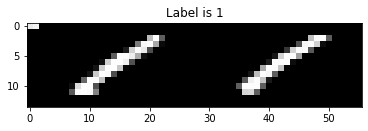

In [21]:
with open('train.csv', 'r') as csv_file:
    header = next(csv_file)
    for data1 in csv.reader(csv_file):
        # The first column is the label
        label = data1[0]

        # The rest of columns are pixels
        pixels = data1[1:]

        # Make those columns into a array of 8-bits pixels
        # This array will be of 1D with length 784
        # The pixel intensity values are integers from 0 to 255
        pixels = np.array(pixels, dtype='uint8')

        # Reshape the array into 28 x 28 array (2-dimensional array)
        pixels = pixels.reshape((14, 56))

        # Plot
        plt.title('Label is {label}'.format(label=label))
        plt.imshow(pixels, cmap='gray')
        plt.show()

        break # This stops the loop, I just want to see one


In [22]:
pixels

array([[233, 243,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 188, 255,  94,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0, 191, 250, 253,  93,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,

In [23]:
Y_train.shape

(41000,)

In [24]:
Y_train

array([1, 5, 1, ..., 7, 6, 9])

NN will have a simple two-layer architecture. Input layer $a^{[0]}$ will have 784 units corresponding to the 784 pixels in each 28x28 input image. A hidden layer $a^{[1]}$ will have 10 units with ReLU activation, and finally output layer $a^{[2]}$ will have 10 units corresponding to the ten digit classes with softmax activation.

**Vars and shapes**

Forward prop

- $A^{[0]} = X$: 784 x m
- $Z^{[1]} \sim A^{[1]}$: 10 x m
- $W^{[1]}$: 10 x 784 (as $W^{[1]} A^{[0]} \sim Z^{[1]}$)
- $B^{[1]}$: 10 x 1
- $Z^{[2]} \sim A^{[2]}$: 10 x m
- $W^{[2]}$: 10 x 10 (as $W^{[2]} A^{[1]} \sim Z^{[2]}$)
- $B^{[2]}$: 10 x 1

Backprop

- $dZ^{[2]}$: 10 x m ($~A^{[2]}$)
- $dW^{[2]}$: 10 x 10
- $dB^{[2]}$: 10 x 1
- $dZ^{[1]}$: 10 x m ($~A^{[1]}$)
- $dW^{[1]}$: 10 x 10
- $dB^{[1]}$: 10 x 1



**Forward propagation**

$$Z^{[1]} = W^{[1]} X + b^{[1]}$$
$$A^{[1]} = g_{\text{ReLU}}(Z^{[1]}))$$
$$Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}$$
$$A^{[2]} = g_{\text{softmax}}(Z^{[2]})$$

**Backward propagation**

$$dZ^{[2]} = A^{[2]} - Y$$
$$dW^{[2]} = \frac{1}{m} dZ^{[2]} A^{[1]T}$$
$$dB^{[2]} = \frac{1}{m} \Sigma {dZ^{[2]}}$$
$$dZ^{[1]} = W^{[2]T} dZ^{[2]} .* g^{[1]\prime} (z^{[1]})$$
$$dW^{[1]} = \frac{1}{m} dZ^{[1]} A^{[0]T}$$
$$dB^{[1]} = \frac{1}{m} \Sigma {dZ^{[1]}}$$

**Parameter updates**

$$W^{[2]} := W^{[2]} - \alpha dW^{[2]}$$
$$b^{[2]} := b^{[2]} - \alpha db^{[2]}$$
$$W^{[1]} := W^{[1]} - \alpha dW^{[1]}$$
$$b^{[1]} := b^{[1]} - \alpha db^{[1]}$$

In [38]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2
W1, b1, W2, b2 = init_params()

In [39]:
W1.shape

(10, 784)

In [40]:
W2

array([[ 0.40032265, -0.02771623,  0.49936322, -0.07390855, -0.27812714,
        -0.41993946,  0.39275443, -0.22515926, -0.46961978,  0.15041264],
       [-0.17538858,  0.20010216, -0.02159536, -0.20817908,  0.34580974,
        -0.39036278, -0.0968154 ,  0.03672079, -0.15619998,  0.26070924],
       [ 0.48951422, -0.34787961, -0.1784288 , -0.27540255, -0.0067916 ,
         0.12118683,  0.05485774,  0.16557508,  0.27091771,  0.06560845],
       [ 0.26143448,  0.2269377 , -0.22677169, -0.44135493,  0.37941347,
         0.41400657, -0.10444371,  0.37656826, -0.10456471,  0.03899916],
       [ 0.34015838,  0.45934715, -0.43717948, -0.23422576,  0.25360245,
        -0.06205364, -0.19457586,  0.40192335, -0.45024527, -0.34366235],
       [-0.24056409,  0.03510836, -0.24820421, -0.11915979, -0.25672915,
         0.43137173, -0.30263373, -0.34767249, -0.31334361, -0.14476736],
       [ 0.40419366,  0.29070158, -0.40152805,  0.48760344,  0.21592265,
        -0.20651842, -0.04645693,  0.30660762

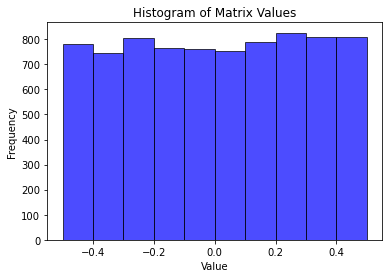

In [41]:
# Flatten the matrix into a 1D array
ddata = W1.flatten()

# Plot histogram
plt.hist(ddata, bins=10, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Matrix Values')
plt.show()

In [42]:
#uniform distribution
def init_params1():
    W1 = np.random.uniform(low=-.05, high=.05, size=(10, 784)) 
    b1 = np.random.uniform(low=-.05, high=.05, size=(10, 1)) 
    W2 = np.random.uniform(low=-.05, high=.05, size=(10, 10)) 
    b2 = np.random.uniform(low=-.05, high=.05, size=(10, 1)) 
    return W1, b1, W2, b2
#W1, b1, W2, b2 = init_params1()

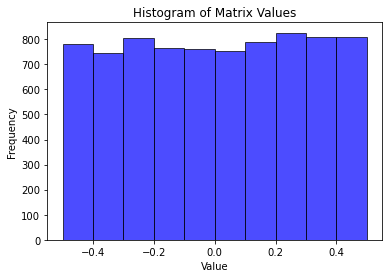

In [43]:
# Flatten the matrix into a 1D array
ddata = W1.flatten()

# Plot histogram
plt.hist(ddata, bins=10, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Matrix Values')
plt.show()

In [44]:
#normal distribution
def init_params2():
    W1 = np.random.normal(0.0, 0.05, size=(10,784))
    b1 = np.random.normal(0.0, 0.05, size=(10, 1))
    W2 = np.random.normal(0.0, 0.05, size=(10, 10))
    b2 = np.random.normal(0.0, 0.05, size=(10, 1))
    return W1, b1, W2, b2
#W1, b1, W2, b2 = init_params2()

In [45]:
W1.shape

(10, 784)

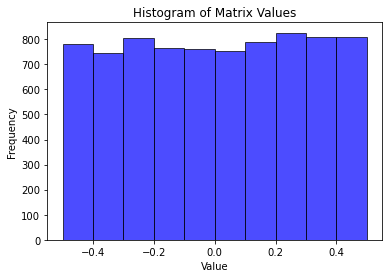

In [46]:
# Flatten the matrix into a 1D array
ddata = W1.flatten()

# Plot histogram
plt.hist(ddata, bins=10, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Matrix Values')
plt.show()

In [47]:
b1.shape

(10, 1)

In [54]:
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

In [56]:
one_hot_Y = one_hot(Y)

NameError: name 'Y' is not defined

In [52]:
def sigmoid(Z):
    ''' It returns 1/(1+exp(-x)). where the values lies between zero and one '''
    return 1/(1+np.exp(-Z))

def sigmoid_derivative(Z):
    return sigmoid(Z)*(1-sigmoid(Z))


def ReLU(Z):
    return np.maximum(Z, 0)


def ReLU_deriv(Z):
    return Z > 0

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    #A1 = sigmoid(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2


def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    W2d = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    #dZ1 = W2.T.dot(dZ2) * sigmoid_derivative(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [53]:
one_hot_Y

NameError: name 'one_hot_Y' is not defined

![Gradient of the softMax Activation Function](SMAX.png)

**One Hot Encodin**

Sometimes in datasets, we encounter columns that contain categorical features (string values) for example parameter Gender will have categorical parameters like Male, Female. These labels have no specific order of preference and also since the data is string labels, the machine learning model can not work on such data.  This method is mostly used when deep learning techniques are to be applied to​ sequential classification problems.

![Examp](One_hot_2.png)
![Examp](One_hot.png)


![Examp](One_hot_1.png)

In [70]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    #print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    # starting time
    start = time.time()
    Accu=[]
    W1, b1, W2, b2 = init_params2()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            #print("Iteration: ", i)
            predictions = get_predictions(A2)
            temp=get_accuracy(predictions, Y)
            temp1=float(temp)
            Accu.append(temp1)
            #print(temp)
        # end time
        end = time.time()
    return W1, b1, W2, b2, Accu, alpha, (end-start)

In [71]:
W1, b1, W2, b2, Accu, Alph, Time = gradient_descent(X_train, Y_train, 0.10, 50)
W1, b1, W2, b2, Accu1, Alph1, Time1 = gradient_descent(X_train, Y_train, 0.15, 50)
W1, b1, W2, b2, Accu2, Alph2, Time2 = gradient_descent(X_train, Y_train, 0.20, 50)
W1, b1, W2, b2, Accu3, Alph3, Time3 = gradient_descent(X_train, Y_train, 0.25, 50)
W1, b1, W2, b2, Accu4, Alph4, Time4 = gradient_descent(X_train, Y_train, 0.30, 50)
W1, b1, W2, b2, Accu5, Alph5, Time5 = gradient_descent(X_train, Y_train, 0.35, 50)
W1, b1, W2, b2, Accu6, Alph6, Time6 = gradient_descent(X_train, Y_train, 0.40, 50)
W1, b1, W2, b2, Accu7, Alph7, Time7 = gradient_descent(X_train, Y_train, 0.45, 50)
W1, b1, W2, b2, Accu8, Alph8, Time8 = gradient_descent(X_train, Y_train, 0.50, 50)
W1, b1, W2, b2, Accu9, Alph9, Time9 = gradient_descent(X_train, Y_train, 0.55, 50)
W1, b1, W2, b2, Accu10, Alph10, Time10 = gradient_descent(X_train, Y_train, 0.60, 50)
W1, b1, W2, b2, Accu11, Alph11, Time11 = gradient_descent(X_train, Y_train, 0.65, 50)

In [76]:
Accu1

[0.12534146341463415,
 0.132,
 0.22358536585365854,
 0.38565853658536586,
 0.5141707317073171]

In [77]:
Time, Time1, Time2, Time3, Time4, Time5, Time6, Time7, Time8, Time9, Time10, Time11

(8.659322738647461,
 7.821126699447632,
 7.916633367538452,
 8.140123128890991,
 8.38205075263977,
 7.846512794494629,
 8.501850128173828,
 8.717886924743652,
 9.589929580688477,
 9.503791332244873,
 9.610933303833008,
 9.735129117965698)

In [78]:
numbersList = []
numbersList.append(Accu)
numbersList.append(Accu1)
numbersList.append(Accu2)
numbersList.append(Accu3)
numbersList.append(Accu4)
numbersList.append(Accu5)
numbersList.append(Accu6)
numbersList.append(Accu7)
numbersList.append(Accu8)
numbersList.append(Accu9)
numbersList.append(Accu10)
numbersList.append(Accu11)
# creating a list of index names
index_values = list(range(0, 50))
# creating a list of column names
column_values  = ['0.10', '0.15','0.20', '0.25','0.30', '0.35', '0.40', '0.45' ,'0.50','0.55','0.60','0.65']
# creating the dataframe
df = pd.DataFrame(data = np.transpose(numbersList),index = index_values,columns = column_values)
# displaying the dataframe
#df
#df.iloc[300:500]

ValueError: Shape of passed values is (5, 12), indices imply (50, 12)

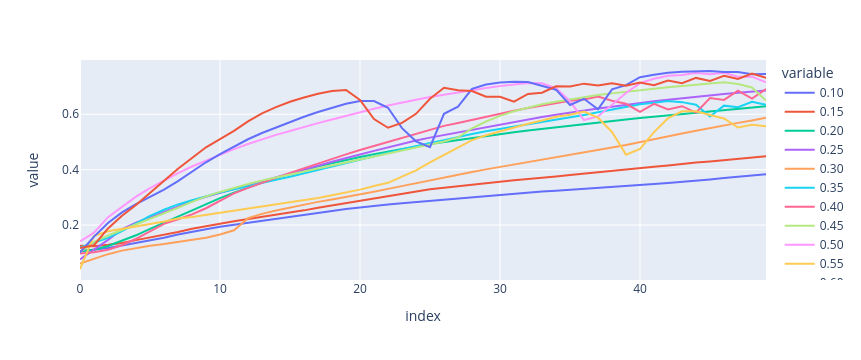

In [79]:
fig = px.line(df, y=['0.10', '0.15','0.20', '0.25','0.30', '0.35', '0.40', '0.45' ,'0.50','0.55','0.60','0.65'])
fig.show()

In [31]:
W1, b1, W2, b2, Accu, Alph, Time = gradient_descent(X_train, Y_train, 0.10, 100)
W1, b1, W2, b2, Accu1, Alph1, Time1 = gradient_descent(X_train, Y_train, 0.15, 100)
W1, b1, W2, b2, Accu2, Alph2, Time2 = gradient_descent(X_train, Y_train, 0.20, 100)
W1, b1, W2, b2, Accu3, Alph3, Time3 = gradient_descent(X_train, Y_train, 0.25, 100)
W1, b1, W2, b2, Accu4, Alph4, Time4 = gradient_descent(X_train, Y_train, 0.30, 100)
W1, b1, W2, b2, Accu5, Alph5, Time5 = gradient_descent(X_train, Y_train, 0.35, 100)
W1, b1, W2, b2, Accu6, Alph6, Time6 = gradient_descent(X_train, Y_train, 0.40, 100)
W1, b1, W2, b2, Accu7, Alph7, Time7 = gradient_descent(X_train, Y_train, 0.45, 100)
W1, b1, W2, b2, Accu8, Alph8, Time8 = gradient_descent(X_train, Y_train, 0.50, 100)
W1, b1, W2, b2, Accu9, Alph9, Time9 = gradient_descent(X_train, Y_train, 0.55, 100)
W1, b1, W2, b2, Accu10, Alph10, Time10 = gradient_descent(X_train, Y_train, 0.60, 100)
W1, b1, W2, b2, Accu11, Alph11, Time11 = gradient_descent(X_train, Y_train, 0.65, 100)

In [32]:
Time, Time1, Time2, Time3, Time4, Time5, Time6, Time7, Time8, Time9, Time10, Time11

(33.98014283180237,
 35.043097734451294,
 32.98745679855347,
 32.5341854095459,
 32.17827582359314,
 32.41654562950134,
 33.35386824607849,
 32.487735986709595,
 32.23178505897522,
 33.20699954032898,
 33.75799345970154,
 34.207664012908936)

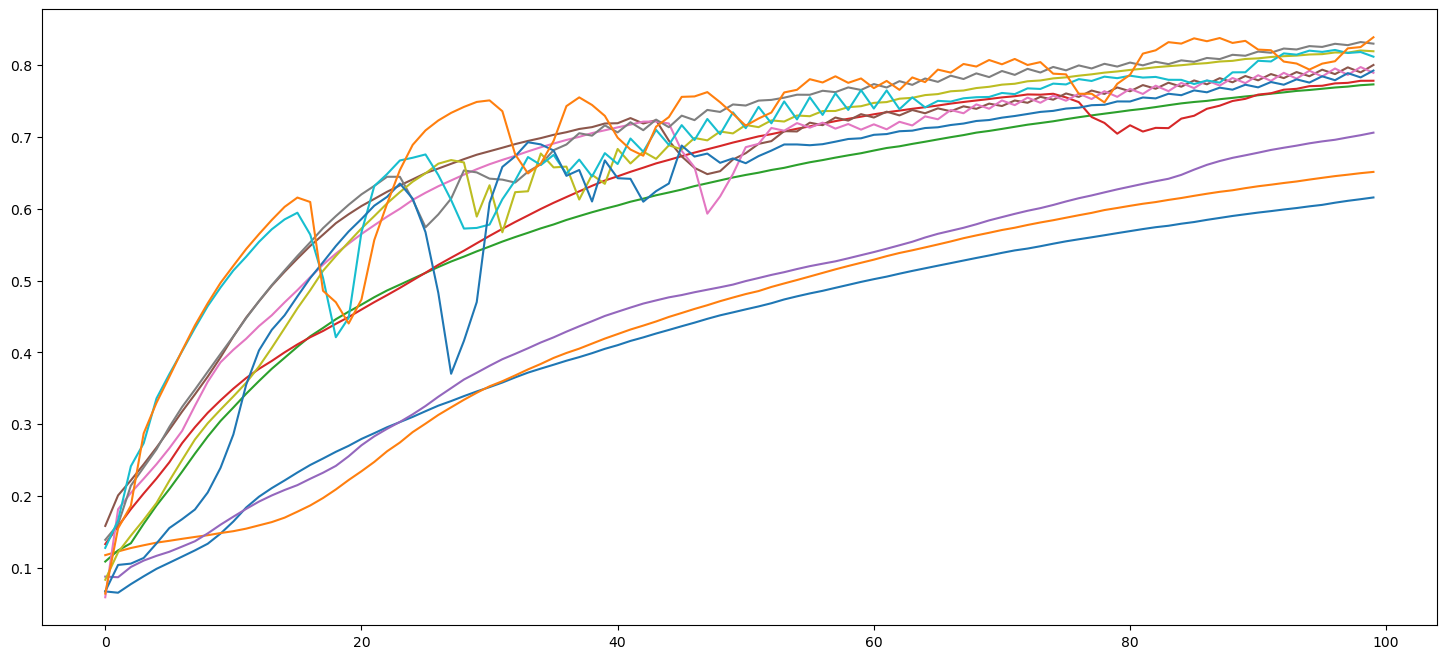

In [33]:
import plotly.graph_objects as go

plt.figure(figsize=(18, 8))
plt.plot(Accu,label=Alph) # plotting by columns
plt.plot(Accu1,label=Alph1)
plt.plot(Accu2,label=Alph2)
plt.plot(Accu3,label=Alph3)
plt.plot(Accu4,label=Alph4)
plt.plot(Accu5,label=Alph5)
plt.plot(Accu6,label=Alph6)
plt.plot(Accu7,label=Alph7)
plt.plot(Accu8,label=Alph8)
plt.plot(Accu9,label=Alph9)
plt.plot(Accu10,label=Alph10)
plt.plot(Accu11,label=Alph11)


In [34]:
numbersList = []
numbersList.append(Accu)
numbersList.append(Accu1)
numbersList.append(Accu2)
numbersList.append(Accu3)
numbersList.append(Accu4)
numbersList.append(Accu5)
numbersList.append(Accu6)
numbersList.append(Accu7)
numbersList.append(Accu8)
numbersList.append(Accu9)
numbersList.append(Accu10)
numbersList.append(Accu11)

# creating a list of index names
index_values = list(range(0, 100))
# creating a list of column names
column_values  = ['0.10', '0.15','0.20', '0.25','0.30', '0.35', '0.40', '0.45' ,'0.50','0.55','0.60','0.65']
# creating the dataframe
df = pd.DataFrame(data = np.transpose(numbersList),index = index_values,columns = column_values)
# displaying the dataframe
#df
#df.iloc[300:500]

In [35]:
import plotly.express as px
fig = px.line(Accu5)
fig.show()

In [36]:
fig = px.line(df, y=['0.10', '0.15','0.20', '0.25','0.30', '0.35', '0.40', '0.45' ,'0.50','0.55','0.60','0.65'])
fig.show()

In [37]:
fig = px.line(df.iloc[0:101], y=['0.10', '0.15','0.20', '0.25','0.30', '0.35', '0.40', '0.45' ,'0.50','0.55','0.60','0.65'])
fig.show()

In [38]:
fig = px.line(df.iloc[75:99], y=['0.10', '0.15','0.20', '0.25','0.30', '0.35', '0.40', '0.45' ,'0.50','0.55','0.60','0.65'])
fig.show()

In [39]:
#with diferent initializars

def gradient_descent(X, Y, alpha, iterations):
    # starting time
    start = time.time()
    Accu=[]
    W1, b1, W2, b2 = init_params2()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 1 == 0:
            #print("Iteration: ", i)
            predictions = get_predictions(A2)
            temp=get_accuracy(predictions, Y)
            temp1=float(temp)
            Accu.append(temp1)
            #print(temp)
        # end time
        end = time.time()
    return W1, b1, W2, b2, Accu, alpha, (end-start)

In [ ]:
W1, b1, W2, b2, Accu, Alph, Time = gradient_descent(X_train, Y_train, 0.10, 50)
W1, b1, W2, b2, Accu1, Alph1, Time1 = gradient_descent(X_train, Y_train, 0.15, 50)
W1, b1, W2, b2, Accu2, Alph2, Time2 = gradient_descent(X_train, Y_train, 0.20, 50)
W1, b1, W2, b2, Accu3, Alph3, Time3 = gradient_descent(X_train, Y_train, 0.25, 50)
W1, b1, W2, b2, Accu4, Alph4, Time4 = gradient_descent(X_train, Y_train, 0.30, 50)
W1, b1, W2, b2, Accu5, Alph5, Time5 = gradient_descent(X_train, Y_train, 0.35, 50)
W1, b1, W2, b2, Accu6, Alph6, Time6 = gradient_descent(X_train, Y_train, 0.40, 50)
W1, b1, W2, b2, Accu7, Alph7, Time7 = gradient_descent(X_train, Y_train, 0.45, 50)
W1, b1, W2, b2, Accu8, Alph8, Time8 = gradient_descent(X_train, Y_train, 0.50, 50)
W1, b1, W2, b2, Accu9, Alph9, Time9 = gradient_descent(X_train, Y_train, 0.55, 50)
W1, b1, W2, b2, Accu10, Alph10, Time10 = gradient_descent(X_train, Y_train, 0.60, 50)
W1, b1, W2, b2, Accu11, Alph11, Time11 = gradient_descent(X_train, Y_train, 0.65, 50)

In [37]:
Time, Time1, Time2, Time3, Time4, Time5, Time6, Time7, Time8, Time9, Time10, Time11

(11.74348521232605,
 11.707738161087036,
 11.62181282043457,
 20.948427438735962,
 10.44891357421875,
 10.465586423873901,
 10.53534722328186,
 10.659006357192993,
 10.25119161605835,
 10.501421451568604,
 9.901265382766724,
 10.720555782318115)

In [38]:
numbersList = []
numbersList.append(Accu)
numbersList.append(Accu1)
numbersList.append(Accu2)
numbersList.append(Accu3)
numbersList.append(Accu4)
numbersList.append(Accu5)
numbersList.append(Accu6)
numbersList.append(Accu7)
numbersList.append(Accu8)
numbersList.append(Accu9)
numbersList.append(Accu10)
numbersList.append(Accu11)
# creating a list of index names
index_values = list(range(0, 50))
# creating a list of column names
column_values  = ['0.10', '0.15','0.20', '0.25','0.30', '0.35', '0.40', '0.45' ,'0.50','0.55','0.60','0.65']
# creating the dataframe
df = pd.DataFrame(data = np.transpose(numbersList),index = index_values,columns = column_values)
# displaying the dataframe
#df
#df.iloc[300:500]

In [39]:
fig = px.line(df, y=['0.10', '0.15','0.20', '0.25','0.30', '0.35', '0.40', '0.45' ,'0.50','0.55','0.60','0.65'])
fig.show()

In [40]:
W1, b1, W2, b2, Accu, Alph, Time = gradient_descent(X_train, Y_train, 0.10, 100)
W1, b1, W2, b2, Accu1, Alph1, Time1 = gradient_descent(X_train, Y_train, 0.15, 100)
W1, b1, W2, b2, Accu2, Alph2, Time2 = gradient_descent(X_train, Y_train, 0.20, 100)
W1, b1, W2, b2, Accu3, Alph3, Time3 = gradient_descent(X_train, Y_train, 0.25, 100)
W1, b1, W2, b2, Accu4, Alph4, Time4 = gradient_descent(X_train, Y_train, 0.30, 100)
W1, b1, W2, b2, Accu5, Alph5, Time5 = gradient_descent(X_train, Y_train, 0.35, 100)
W1, b1, W2, b2, Accu6, Alph6, Time6 = gradient_descent(X_train, Y_train, 0.40, 100)
W1, b1, W2, b2, Accu7, Alph7, Time7 = gradient_descent(X_train, Y_train, 0.45, 100)
W1, b1, W2, b2, Accu8, Alph8, Time8 = gradient_descent(X_train, Y_train, 0.50, 100)
W1, b1, W2, b2, Accu9, Alph9, Time9 = gradient_descent(X_train, Y_train, 0.55, 100)
W1, b1, W2, b2, Accu10, Alph10, Time10 = gradient_descent(X_train, Y_train, 0.60, 100)
W1, b1, W2, b2, Accu11, Alph11, Time11 = gradient_descent(X_train, Y_train, 0.65, 100)

In [41]:
Time, Time1, Time2, Time3, Time4, Time5, Time6, Time7, Time8, Time9, Time10, Time11

(21.077188730239868,
 21.017483711242676,
 21.556135892868042,
 19.876073598861694,
 20.09597635269165,
 19.843090772628784,
 19.78497052192688,
 19.673434734344482,
 19.943130254745483,
 19.88536262512207,
 20.06271743774414,
 20.043347597122192)

In [42]:
numbersList = []
numbersList.append(Accu)
numbersList.append(Accu1)
numbersList.append(Accu2)
numbersList.append(Accu3)
numbersList.append(Accu4)
numbersList.append(Accu5)
numbersList.append(Accu6)
numbersList.append(Accu7)
numbersList.append(Accu8)
numbersList.append(Accu9)
numbersList.append(Accu10)
numbersList.append(Accu11)
# creating a list of index names
index_values = list(range(0, 100))
# creating a list of column names
column_values  = ['0.10', '0.15','0.20', '0.25','0.30', '0.35', '0.40', '0.45' ,'0.50','0.55','0.60','0.65']
# creating the dataframe
df = pd.DataFrame(data = np.transpose(numbersList),index = index_values,columns = column_values)
# displaying the dataframe
#df
#df.iloc[300:500]

In [43]:
fig = px.line(df, y=['0.10', '0.15','0.20', '0.25','0.30', '0.35', '0.40', '0.45' ,'0.50','0.55','0.60','0.65'])
fig.show()

In [44]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [2]
Label:  2


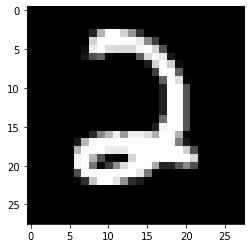

Prediction:  [5]
Label:  5


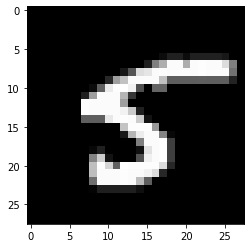

Prediction:  [7]
Label:  7


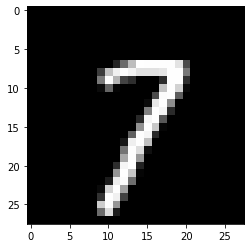

Prediction:  [9]
Label:  9


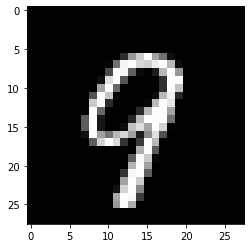

Prediction:  [3]
Label:  3


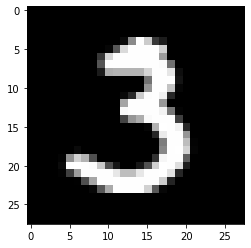

In [45]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)
test_prediction(8, W1, b1, W2, b2)

In [46]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

0.864